<a href="https://colab.research.google.com/github/ghzaid/aiml/blob/main/AiLabContinuousEvaluationProblem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx matplotlib


BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


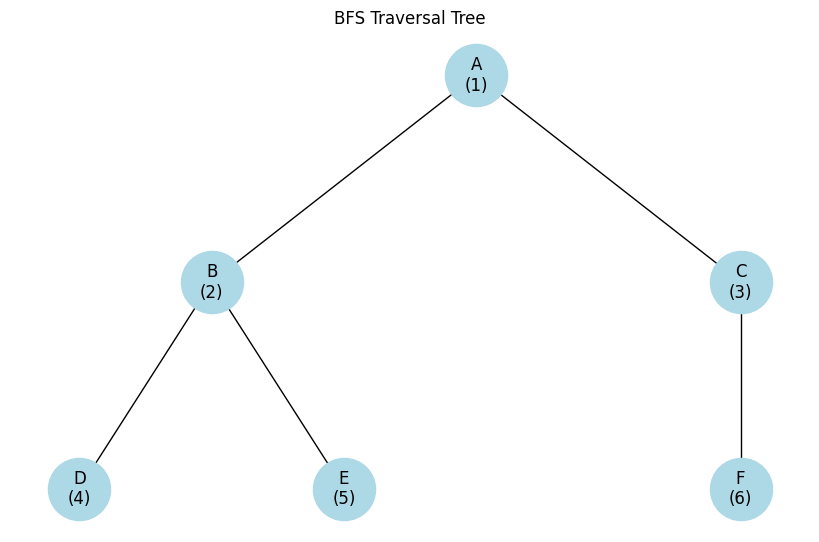

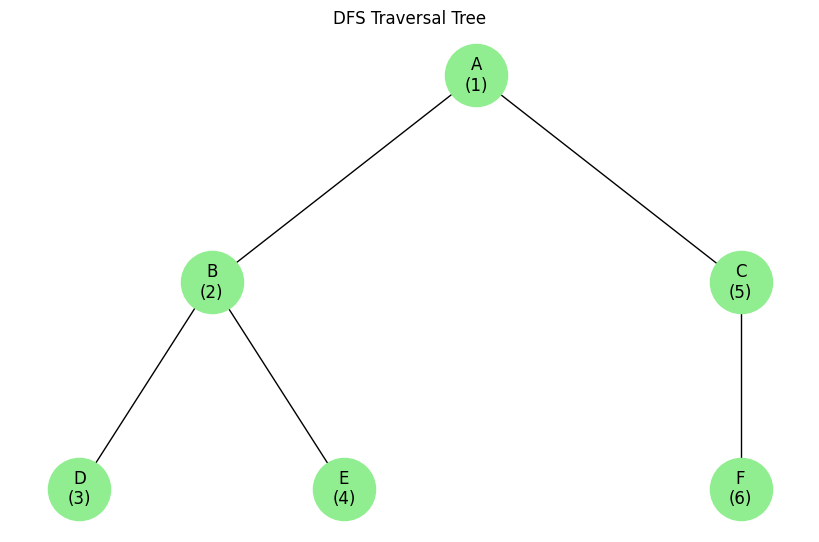

In [3]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------
# 1. Adjacency List
# -------------------------------
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}


# -------------------------------
# 2. BFS Traversal
# -------------------------------
def bfs(graph, start):
    visited = set()
    queue = deque([start])
    order = []

    visited.add(start)

    while queue:
        node = queue.popleft()
        order.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    return order


# -------------------------------
# 3. DFS Traversal
# -------------------------------
def dfs(graph, start, visited=None, order=None):

    if visited is None:
        visited = set()

    if order is None:
        order = []

    visited.add(start)
    order.append(start)

    for neighbour in graph[start]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited, order)

    return order


# Perform BFS and DFS
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))


# -------------------------------
# 4. Draw BFS Tree
# -------------------------------

def draw_bfs_tree(graph, bfs_order):

    G = nx.Graph()

    # Add edges from the original tree
    for node in graph:
        for neighbour in graph[node]:
            G.add_edge(node, neighbour)

    # Position nodes manually
    position = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    plt.figure(figsize=(8, 5))

    nx.draw(
        G,
        position,
        with_labels=False,
        node_size=2000,
        node_color='lightblue',
        edge_color='black'
    )

    # Display BFS visit order inside nodes
    labels = {
        node: f"{node}\n({bfs_order.index(node) + 1})"
        for node in bfs_order
    }

    nx.draw_networkx_labels(
        G,
        position,
        labels=labels,
        font_size=12
    )

    plt.title("BFS Traversal Tree")
    plt.axis("off")
    plt.show()


# -------------------------------
# Draw DFS Tree
# -------------------------------

def draw_dfs_tree(graph, dfs_order):

    G = nx.Graph()

    # Add edges
    for node in graph:
        for neighbour in graph[node]:
            G.add_edge(node, neighbour)

    # Position nodes
    position = {
        'A': (0, 2),
        'B': (-1, 1),
        'C': (1, 1),
        'D': (-1.5, 0),
        'E': (-0.5, 0),
        'F': (1, 0)
    }

    plt.figure(figsize=(8, 5))

    nx.draw(
        G,
        position,
        with_labels=False,
        node_size=2000,
        node_color='lightgreen',
        edge_color='black'
    )

    # Display DFS visit order inside nodes
    labels = {
        node: f"{node}\n({dfs_order.index(node) + 1})"
        for node in dfs_order
    }

    nx.draw_networkx_labels(
        G,
        position,
        labels=labels,
        font_size=12
    )

    plt.title("DFS Traversal Tree")
    plt.axis("off")
    plt.show()


# Draw both trees
draw_bfs_tree(graph, bfs_order)
draw_dfs_tree(graph, dfs_order)